# Darts - Temporal Fusion Transformer (TFT)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from darts import TimeSeries
import darts.metrics as metrics
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller

import torch
from pytorch_lightning.callbacks import EarlyStopping

In [108]:
file = "datas/magnific7_1day.pkl"
series_dict = pd.read_pickle(file)

### Détection des trous dans les dates

In [109]:
for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    full_series = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")
    missing_dates = full_series.difference(df.index)

    print(f"{name}: {len(missing_dates)} dates manquantes")


APPLE: 143 dates manquantes
MICROSOFT: 143 dates manquantes
AMAZON: 143 dates manquantes
ALPHABET: 143 dates manquantes
NVIDIA: 143 dates manquantes
META: 123 dates manquantes
TESLA: 139 dates manquantes


### Conversion des 7 dataframes en time series

In [110]:
global_min_date = pd.Timestamp.max 
global_max_date = pd.Timestamp.min

for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)
    if not df.empty:
        global_min_date = min(global_min_date, df.index.min())
        global_max_date = max(global_max_date, df.index.max())

if global_min_date == pd.Timestamp.max or global_max_date == pd.Timestamp.min:
    raise ValueError("Aucune donnée valide trouvée dans series_dict pour déterminer l'index temporel global.")

full_global_time_index = pd.date_range(start=global_min_date, end=global_max_date, freq='B')


In [111]:
filler = MissingValuesFiller()

all_series = []
all_past_covariates = []

for name, df_original in series_dict.items():
    df_original.index = pd.to_datetime(df_original.index)

    df_reindexed = df_original.reindex(full_global_time_index)

    df_filled = df_reindexed.fillna(method='ffill').fillna(method='bfill')
    df_filled = df_filled.fillna(df_filled.mean())

    ts = TimeSeries.from_dataframe(df_filled, value_cols='close', fill_missing_dates=True, freq='B')
    ts = filler.transform(ts)
    all_series.append(ts)

    ts_past_covariates = TimeSeries.from_dataframe(df_filled, value_cols=['open', 'high', 'low', 'volume'], fill_missing_dates=True, freq='B')
    ts_past_covariates = filler.transform(ts_past_covariates)
    all_past_covariates.append(ts_past_covariates)


/tmp/ipykernel_1198/853977056.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_reindexed.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1198/853977056.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_reindexed.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1198/853977056.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_reindexed.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1198/853977056.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_reindexed.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_1

### Séparation du jeu de données

In [112]:
train_series = []
val_series = []
train_past_covariates = []
val_past_covariates = []

for ts_target, ts_covariates in zip(all_series,  all_past_covariates):
    split_index = ts_target.split_before(0.8)[0].time_index[-1]# Obtenir la dernière date de la série d'entraînement
    train_close, val_close = ts.split_before(0.8)
    train_series.append(train_close)
    val_series.append(val_close)

    train_cov, val_cov = ts_covariates.split_before(split_index)
    train_past_covariates.append(train_cov)
    val_past_covariates.append(val_cov)

### Normalisation des données

In [113]:
close_scalers = []
past_cov_scalers = []

train_series_scaled = []
val_series_scaled = []
train_past_covariates_scaled = []
val_past_covariates_scaled = []

for i in range(len(train_series)):
    close_scaler = Scaler(StandardScaler())
    train_scaled = close_scaler.fit_transform(train_series[i])
    val_scaled = close_scaler.transform(val_series[i])

    close_scalers.append(close_scaler)
    train_series_scaled.append(train_scaled)
    val_series_scaled.append(val_scaled)

    past_cov_scaler = Scaler(StandardScaler())
    train_cov_scaled = past_cov_scaler.fit_transform(train_past_covariates[i])
    val_cov_scaled = past_cov_scaler.transform(val_past_covariates[i])

    past_cov_scalers.append(past_cov_scaler)
    train_past_covariates_scaled.append(train_cov_scaled)
    val_past_covariates_scaled.append(val_cov_scaled)

### Vérification Cuda

In [114]:
if torch.cuda.is_available():
    print(f"CUDA est disponible ! Nombre de GPUs : {torch.cuda.device_count()}")
    gpu_devices = [0]
else:
    print("CUDA n'est pas disponible. Utilisation du CPU.")
    gpu_devices = 0

CUDA est disponible ! Nombre de GPUs : 1


### Implémentation de EarlyStopping

In [115]:
early_stopper = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.05,
    mode='min'
)

pl_trainer_kwargs={
    "callbacks": [
        early_stopper
    ],
    "accelerator": "gpu",
    "devices": gpu_devices
}

## Modèle TFT

In [116]:
model_tft = TFTModel(
    model_name="TFT",
    input_chunk_length=60,
    output_chunk_length=30,
    hidden_size=128,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32, # ou 64 si beaucoup de RAM sur GPU
    n_epochs=100,
    add_relative_index=True,
    likelihood=None,
    random_state=42,
    optimizer_kwargs={"lr": 5e-4},
    force_reset=True,
    log_tensorboard=True,
    pl_trainer_kwargs=pl_trainer_kwargs,
    )

try:
    model_tft.fit(
        series=train_series_scaled,
        past_covariates=train_past_covariates_scaled,
        val_series=val_series_scaled,
        val_past_covariates=val_past_covariates_scaled,
        verbose=True
    )
    print("Entraînement du TFT terminé avec succès !")
except ValueError as e:
    print(f"Erreur lors de l'entraînement du TFT : {e}")
    print("\nVérifiez les longueurs et l'alignement temporel de vos séries et covariables.")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 19.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 3.1 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 66.3 K | train
7  | static_cont

Epoch 31: 100%|██████████| 679/679 [00:59<00:00, 11.34it/s, v_num=logs, train_loss=0.120, val_loss=4.110]     
Entraînement du TFT terminé avec succès !


In [118]:
model_tft.save("./models/model_tft.pickle")
print("Modèle TFT enregistré avec succès !")

Modèle TFT enregistré avec succès !


In [120]:
loaded_model_tft = TFTModel.load("./models/model_tft.pickle")
print("Modèle TFT chargé avec succès !")

Modèle TFT chargé avec succès !


### Evaluation du model

In [123]:
def evaluate_model_historical_forecasts(model, 
                   train_series_scaled, val_series_scaled, target_scalers_list,
                   train_past_covariates_scaled=None, past_cov_scalers_list=None, past_cov_scaler=None,
                   forecast_horizon=None):

    """
    Évalue un modèle Darts en utilisant la méthode historical_forecasts()
    sur les séries de validation, en gérant les covariables passées.

    Args:
        model: Le modèle Darts entraîné.
        train_series_scaled: Liste des séries d'entraînement mises à l'échelle (cible).
        val_series_scaled: Liste des séries de validation mises à l'échelle (cible).
        target_scaler: Le scaler utilisé pour les séries cibles (pour la dénormalisation).
        train_past_covariates_scaled: Liste des covariables passées d'entraînement mises à l'échelle (optionnel).
        val_past_covariates_scaled: Liste des covariables passées de validation mises à l'échelle (optionnel).
        past_cov_scaler: Le scaler utilisé pour les covariables passées (pour la dénormalisation, si besoin).
        forecast_horizon: L'horizon de prédiction désiré (n dans predict).
                          Si None, utilise output_chunk_length du modèle.

    Returns:
        pd.DataFrame: Un DataFrame contenant les métriques MAE, RMSE et MAPE
                      pour chaque série évaluée.
        list: Liste des prédictions dénormalisées pour chaque série.
    """

    if forecast_horizon is None:
        forecast_horizon = model.output_chunk_length

    performance = {}
    all_denormalized_predictions = []

    # Vérification de la présence de covariables passées
    use_past_covariates = train_past_covariates_scaled is not None and val_past_covariates_scaled is not None

    # Boucle sur chaque série
    for i in range(len(val_series_scaled)):
        current_train_series = train_series_scaled[i]
        current_val_series = val_series_scaled[i]
        current_target_scaler = target_scalers_list[i] 

        #  Concatenation des séries d'entraînement et de validation
        full_series_for_backtest = current_train_series.append(current_val_series)

        current_past_covariates = None
        if use_past_covariates:
            current_train_past_cov = train_past_covariates_scaled[i]
            current_val_past_cov = val_past_covariates_scaled[i]
            current_past_covariates_for_backtest = current_train_past_cov.append(current_val_past_cov)

        #Définir le pout de départ pour historical_forecasts
        start_val_time = current_val_series.start_time()

        # Prédictions historiques
        try:
            if use_past_covariates:
                predictions_scaled = model.historical_forecasts(
                    series=full_series_for_backtest,
                    past_covariates=current_past_covariates_for_backtest,
                    start=start_val_time,
                    forecast_horizon=forecast_horizon,
                    stride=1,
                    retrain=False,
                    last_points_only=True,
                    verbose=False
                )
            else:
                predictions_scaled = model.historical_forecasts(
                    series=full_series_for_backtest,
                    start=start_val_time,
                    forecast_horizon=forecast_horizon,
                    stride=1,
                    retrain=False,
                    last_points_only=True,
                    verbose=False
                )        
        except Exception as e:
            print(f"Erreur lors de l'évaluation de la série {i}: {e}")
            predictions_scaled = TimeSeries.from_times_and_values(current_val_series.time_index[:0], np.array([]))

        # Dénormalisation des prédictions
        pred = current_target_scaler.inverse_transform(predictions_scaled)
        actual = current_target_scaler.inverse_transform(current_val_series)

        #  Alignement des séries sur la période actual 
        pred_aligned = pred.slice_intersect(actual)
        actual_aligned = actual.slice_intersect(pred)

        all_denormalized_predictions.append(pred_aligned)

        #  Calcul des métriques
        if len(actual_aligned) > 0 and len(pred_aligned) > 0:
            mae_value = metrics.mae(actual_aligned, pred_aligned)
            rmse_value = metrics.rmse(actual_aligned, pred_aligned)
            mape_value = metrics.mape(actual_aligned, pred_aligned)
        else:
            mae_value, rmse_value, mape_value = np.nan, np.nan, np.nan

        performance[f'Série {i}'] = {
            "MAE": mae_value,
            "RMSE": rmse_value,
            "MAPE": mape_value
        }
    
    return pd.DataFrame(performance).T, all_denormalized_predictions

In [124]:
perf_df_historical_forecast, all_predictions_fot_plot = evaluate_model_historical_forecasts(
    loaded_model_tft,
    train_series_scaled,
    val_series_scaled,
    close_scalers,
    train_past_covariates_scaled,
    val_past_covariates_scaled,
    past_cov_scalers,
    forecast_horizon=model_tft.output_chunk_length
)
print(perf_df_historical_forecast) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 2:  52%|█████▏    | 355/679 [1:59:14<1:48:49,  0.05it/s, v_num=logs, train_loss=0.261, val_loss=3.240]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


               MAE       RMSE       MAPE
Série 0  64.399615  77.393961  29.885750
Série 1  63.336166  75.645920  29.175094
Série 2  57.859059  70.202394  26.094147
Série 3  61.733775  73.903213  28.270267
Série 4  62.995166  74.815436  28.977588
Série 5  55.981237  67.244208  25.839466
Série 6  64.147819  78.733204  29.145203


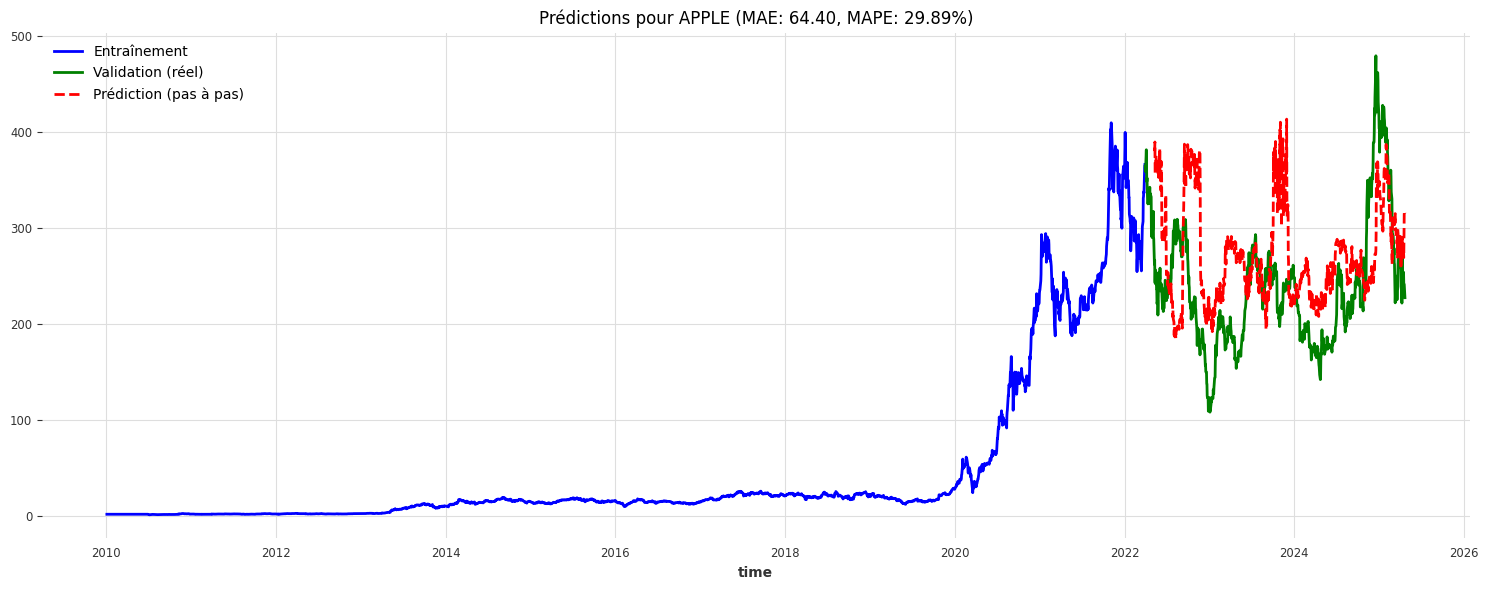

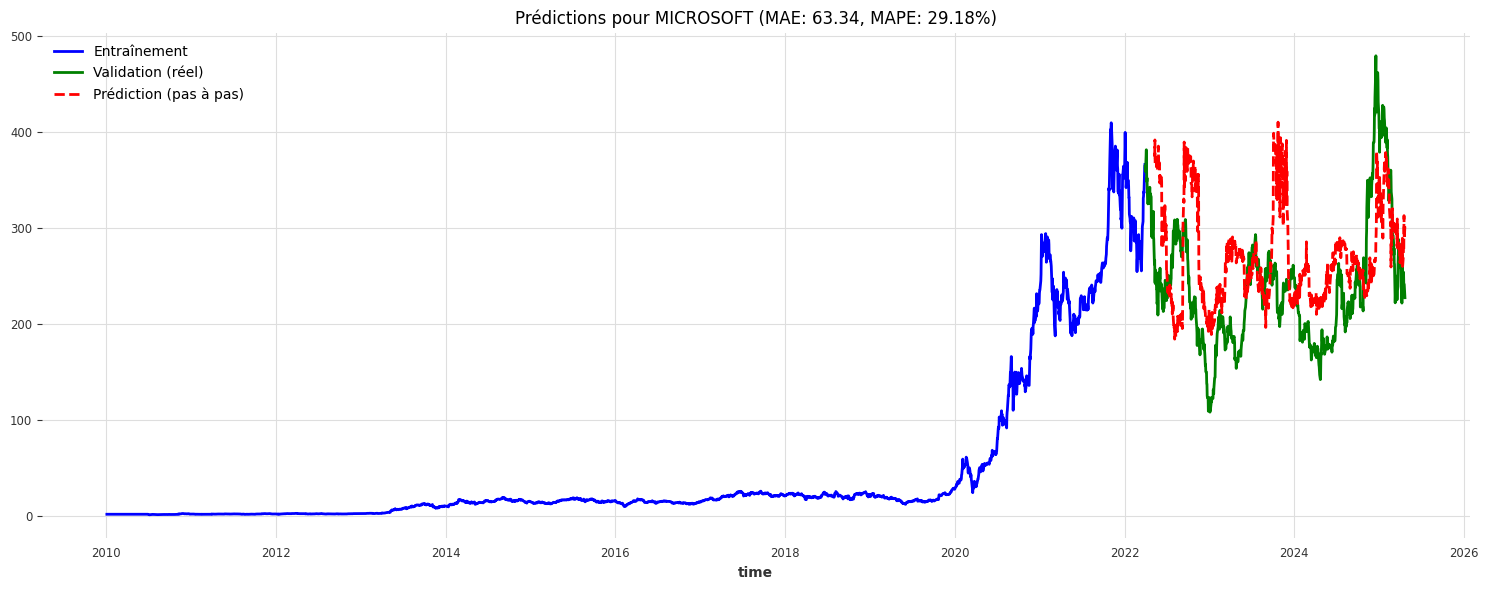

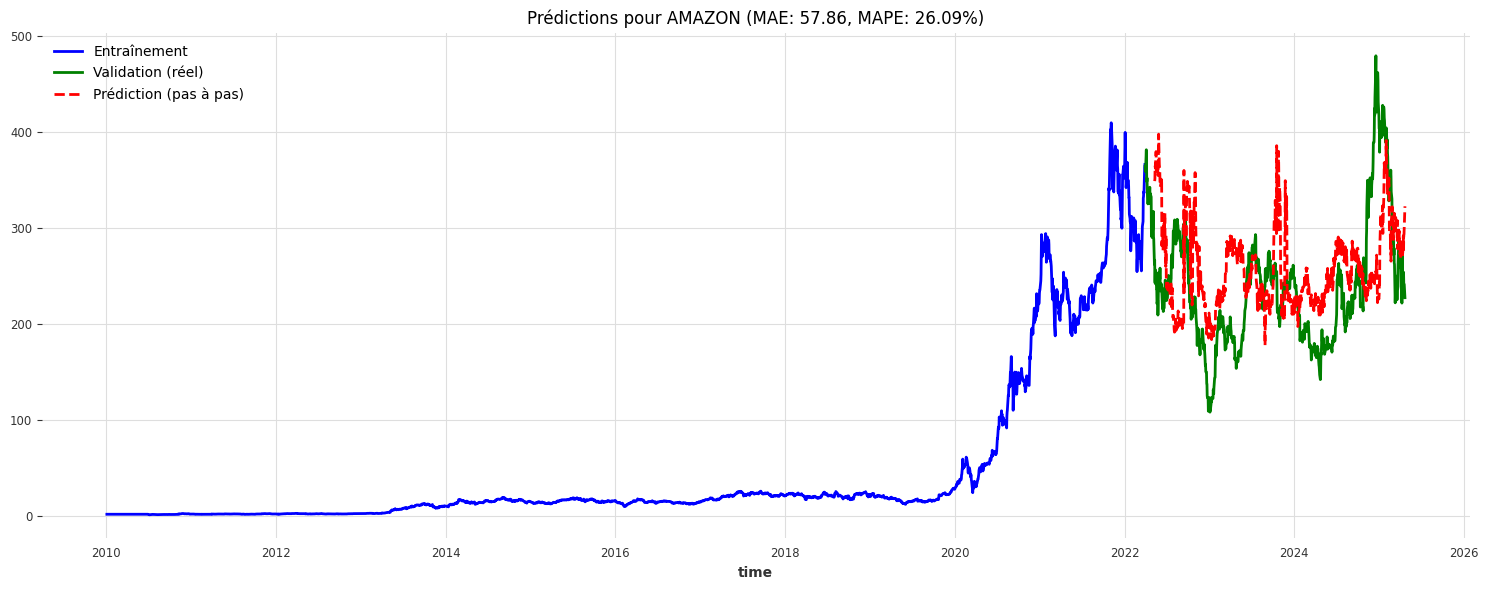

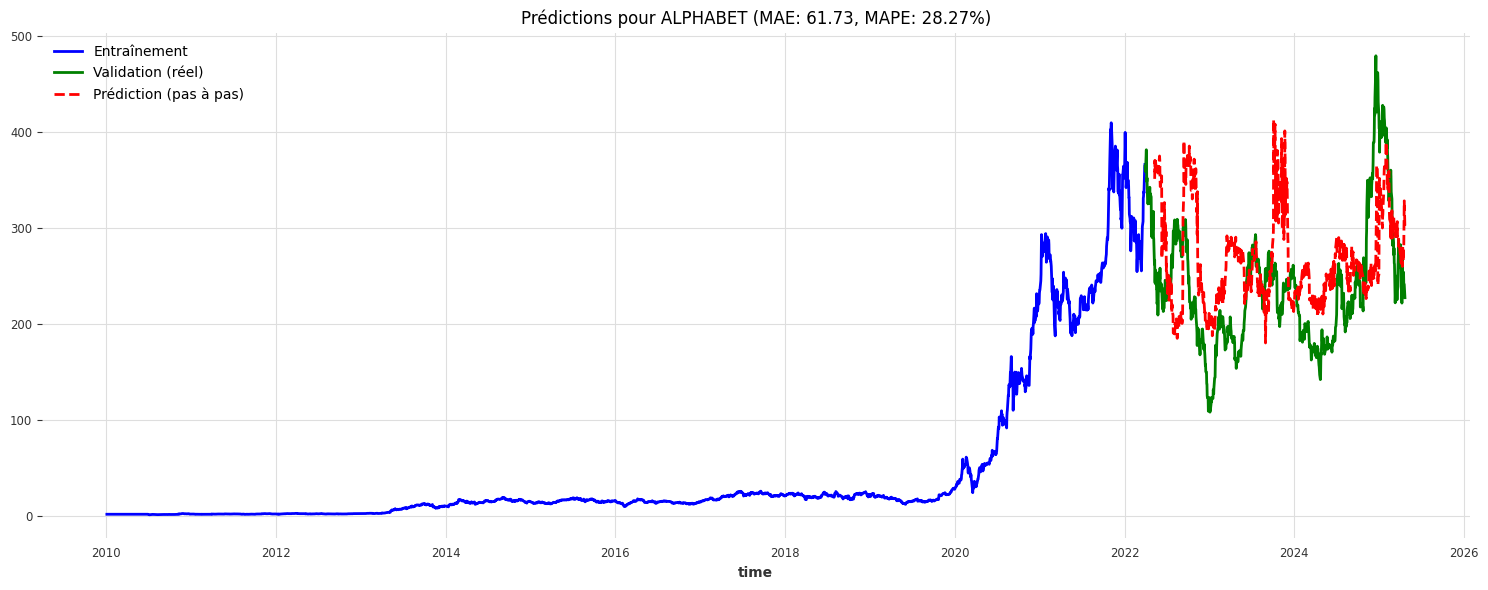

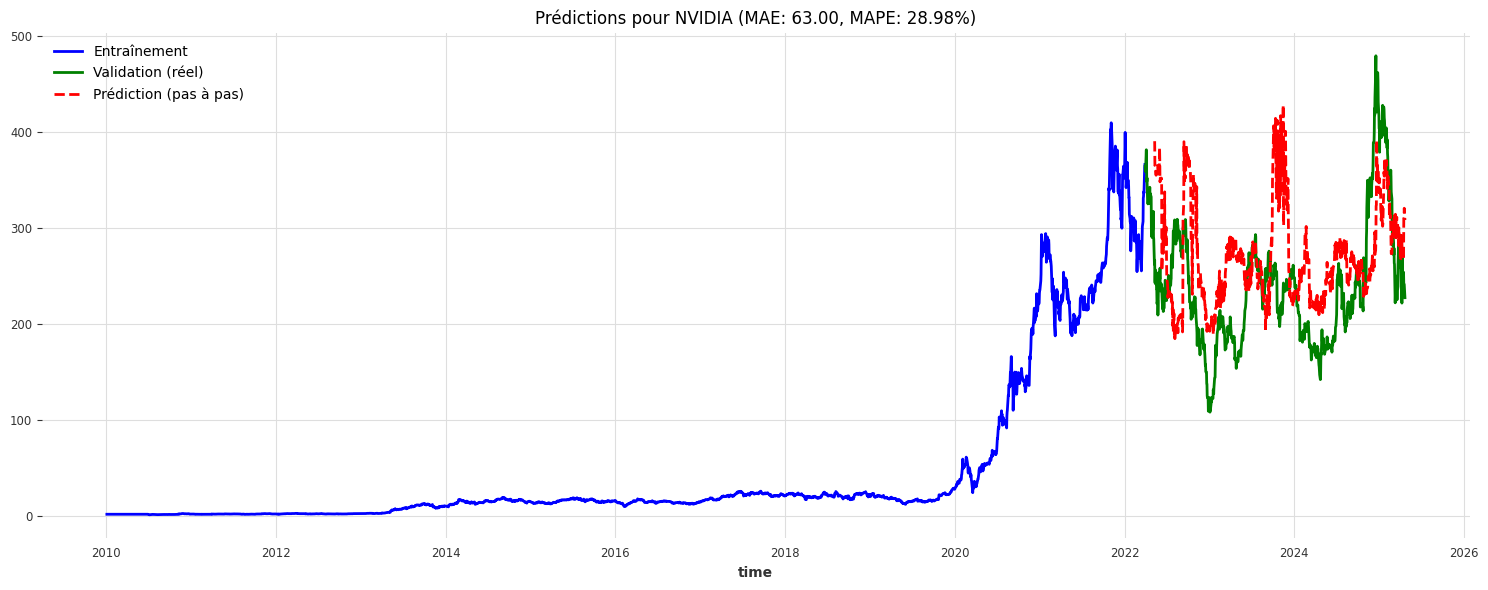

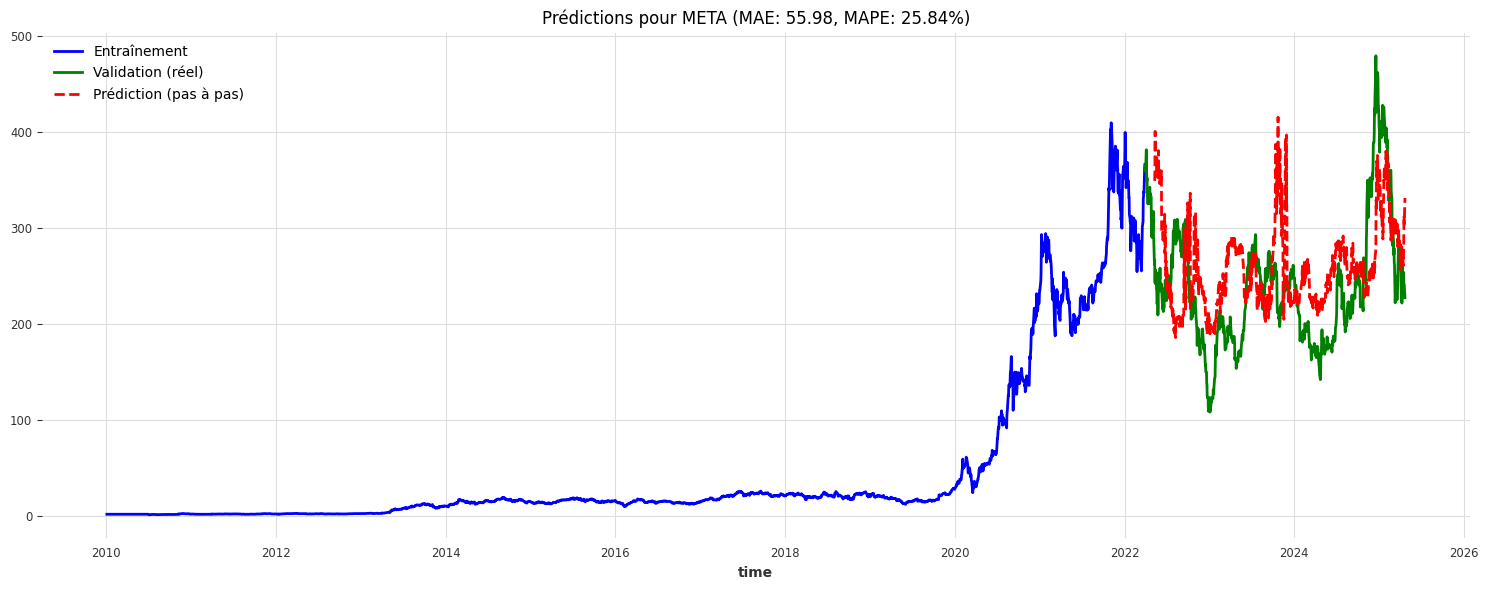

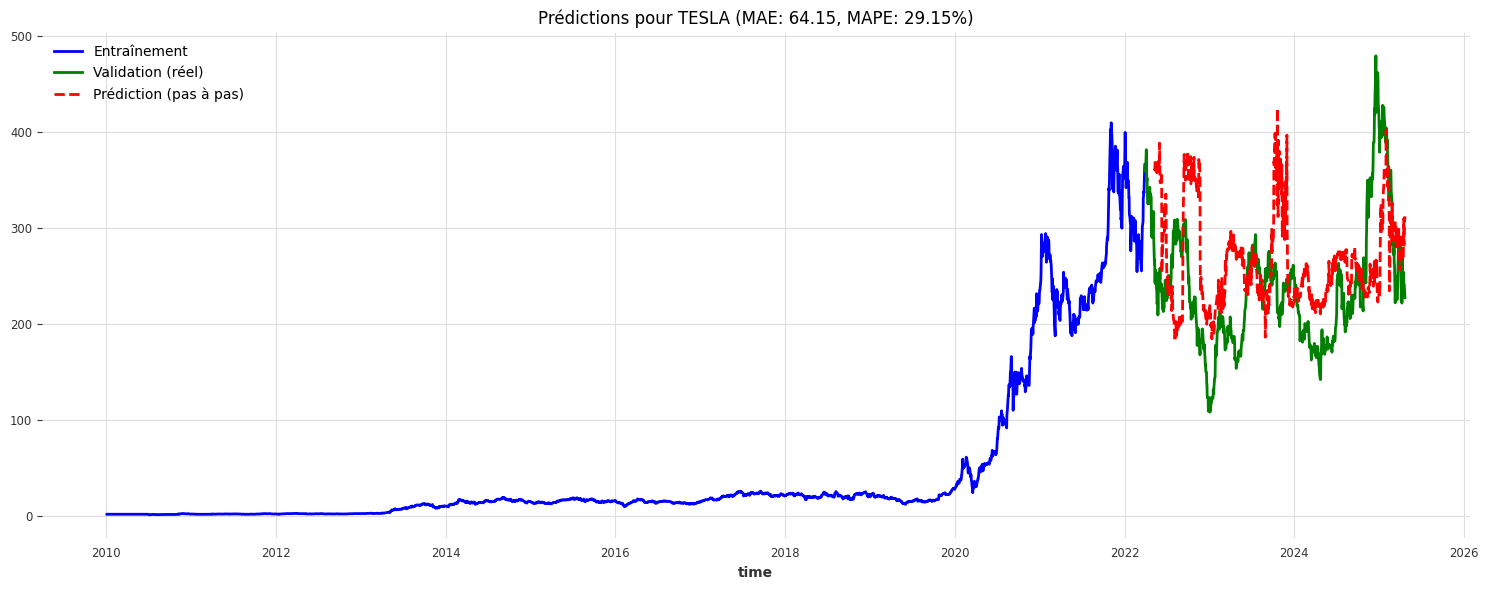

In [125]:
company_names = ['APPLE', 'MICROSOFT', 'AMAZON', 'ALPHABET', 'NVIDIA', 'META', 'TESLA']

# Pour chaque série (entreprise)
for idx in range(len(train_series)):
    # Récupérer les données d'entraînement et de validation
    train_data = train_series[idx]
    val_data = val_series[idx]
    
    pred_data = all_predictions_fot_plot[idx]

    mae_val = perf_df_historical_forecast.loc[f'Série {idx}', 'MAE']
    mape_val = perf_df_historical_forecast.loc[f'Série {idx}', 'MAPE']

    # Créer une nouvelle figure pour chaque entreprise
    plt.figure(figsize=(15, 6))

    # Tracer les séries temporelles
    train_data.plot(label='Entraînement', color='blue')
    val_data.plot(label='Validation (réel)', color='green')
    pred_data.plot(label='Prédiction (pas à pas)', color='red', linestyle='--')

    # Ajouter titre et légende avec métriques
    plt.title(f'Prédictions pour {company_names[idx]} (MAE: {mae_val:.2f}, MAPE: {mape_val:.2f}%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Analyse des performances du TFT par entreprise
Série 5 (META) : Se démarque avec les meilleures performances, affichant le MAPE le plus bas à 25.84%. Cela suggère que le modèle TFT parvient le mieux à capturer la dynamique de cette série.<br>
Série 2 (AMAZON) : Montre une performance solide, avec le deuxième meilleur MAPE à 26.09%, indiquant une bonne capacité du modèle à prédire ses mouvements.<br>
Série 3 (ALPHABET) : Ses prévisions se situent dans une fourchette moyenne, avec un MAPE de 28.27%.<br>
Série 4 (NVIDIA) : Présente des résultats comparables à Alphabet, avec un MAPE de 28.98%.<br>
Série 1 (MICROSOFT) : Affiche un MAPE de 29.18%, se classant également dans le milieu de tableau en termes de prédictibilité.<br>
Série 6 (TESLA) : Rencontre un peu plus de difficultés, avec un MAPE de 29.15%.<br>
Série 0 (APPLE) : Enregistre le MAPE le plus élevé à 29.89%, ce qui indique que cette série est la plus difficile à prédire pour le modèle TFT dans votre ensemble de données. Cela peut être dû à une volatilité plus importante ou à des motifs de prix plus complexes.<br>
<br>
#### Conclusion générale
Ces résultats actualisés confirment que le modèle TFT est pleinement fonctionnel et capable de générer des prévisions, même si la précision varie d'une série à l'autre. Les MAPE sont globalement plus élevés que dans votre analyse précédente, ce qui est une information cruciale à prendre en compte.